# EDA: Clientes, Soporte y Churn

## Caso Práctico - Empresa de Telecomunicaciones
## MBI — Prácticas Aplicadas 2026

---

Este notebook recoge el análisis exploratorio de datos (EDA) de las tres fuentes principales del caso de predicción de churn en una empresa de telecomunicaciones:

- `clientes.csv` → Perfil sociodemográfico y comercial de los clientes
- `interacciones_soporte.csv` → Historial de contactos con el servicio de atención al cliente
- `churn_target.csv` → Panel mensual con la etiqueta de abandono

El objetivo de este EDA no es construir un modelo todavía, sino **entender la estructura de los datos**, detectar problemas de calidad, y generar **hipótesis sobre qué variables podrían ser relevantes** para predecir el churn.

La idea es ir de lo general a lo específico: primero entender cada tabla por separado, y después cruzarlas para buscar patrones relacionados con el abandono.

## Objetivos del notebook

1. Explorar la estructura y calidad de las tres fuentes de datos
2. Construir una tabla analítica por cliente integrando soporte + clientes + churn
3. Analizar el desbalance de la variable objetivo y la distribución temporal del churn
4. Contrastar hipótesis sobre el perfil del cliente que abandona:
   - H1: ¿Los clientes premium llaman más? ¿Abandonan más o menos?
   - H2: ¿El motivo de la llamada está relacionado con el churn?
   - H3: ¿La resolución de las llamadas está relacionada con el churn?
   - H4: ¿Los clientes con menor antigüedad abandonan más?
   - H5: ¿La zona/región influye en el tipo de llamadas o en el churn?
   - H6: ¿Los ingresos o descuentos activos están relacionados con el churn?
   - H7: ¿La satisfacción post-interacción predice el churn?
   - H8: ¿El comportamiento de pago (impagos/retrasos) está relacionado con el abandono?


## Nota metodológica

Las tres tablas operan en niveles distintos:

- `clientes.csv` → **1 fila por cliente** (datos estáticos)
- `churn_target.csv` → **1 fila por cliente-mes** (panel temporal)
- `interacciones_soporte.csv` → **1 fila por interacción** (pueden ser múltiples por cliente y mes)

Para el EDA vamos a trabajar en **dos niveles**:
1. **Nivel interacción**: para analizar patrones en el comportamiento de soporte
2. **Nivel cliente**: agregando soporte y churn por cliente para cruzar con el perfil

Para el churn usaremos la etiqueta `ever_churn = 1` si el cliente churneó en algún momento del horizonte observado. Es una simplificación para el EDA, pero suficiente para identificar correlatos del abandono.


## 1. Librerías e importaciones


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu
from pathlib import Path
import sys
sys.path.append(str(Path('..').resolve()))

from src.load  import load_clientes, load_churn, load_soporte
from src.utils import missing_summary, cramers_v, summarize_rate

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', context='notebook')
PALETTE_CHURN = {0: '#4C9BE8', 1: '#E85C4C'}
print('Librerías cargadas')


Librerías cargadas


## 2. Funciones auxiliares

Defino algunas funciones reutilizables para no repetir código a lo largo del notebook.


In [3]:
# Funciones auxiliares importadas desde src/utils
# missing_summary, cramers_v, summarize_rate
print('Funciones auxiliares listas')


Funciones auxiliares listas


## 3. Carga de datos


In [4]:
# Cargamos los CSV crudos sin limpieza de negocio
clientes = load_clientes()
churn    = load_churn()
soporte  = load_soporte()

print(f'clientes:  {clientes.shape}')
print(f'churn:     {churn.shape}')
print(f'soporte:   {soporte.shape}')


[load] clientes:    10,150 filas x 14 columnas
[load] churn:       321,987 filas x 3 columnas
[load] soporte:     308,487 filas x 13 columnas
clientes:  (10150, 14)
churn:     (321987, 3)
soporte:   (308487, 13)


---
## 4. EDA — Tabla de Clientes

Empezamos explorando la tabla de clientes. Esta tabla contiene el perfil estático de cada cliente: datos demográficos, tipo de plan, características de la zona, etc. Es la base sobre la que construiremos la tabla analítica.


In [5]:
print(f'clientes: {clientes.shape}')
display(missing_summary(clientes))
print('\n--- Primeras filas ---')
display(clientes.head())


clientes: (10150, 14)


,n_missing,pct_missing,dtype
edad,305,3.00,float64
antiguedad_meses,305,3.00,float64
ingreso_estimado,304,3.00,float64
estado_civil,79,0.78,object
sexo,45,0.44,object
cliente_id,0,0.00,object
zona_id,0,0.00,object
region,0,0.00,object
tipo_zona,0,0.00,object
poblacion_zona,0,0.00,int64



--- Primeras filas ---


,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
0,C000001,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0
1,C000002,Z15,Oeste,suburbana,62939,54.00,M,Casado/a,2,Premium,Gama media,"4,609.00",35.00,1
2,C000003,Z27,Norte,suburbana,42704,54.00,M,Casado/a,3,Prepago,Gama baja,"1,836.00",11.00,0
3,C000004,Z22,Este,suburbana,53534,34.00,M,Soltero/a,1,Prepago,Gama media,"2,318.00",13.00,0
4,C000005,Z04,Centro,suburbana,55457,46.00,F,Soltero/a,2,Contrato,Gama media,"2,184.00",21.00,0


### 4.1 Descripción estadística

Antes de entrar en hipótesis, es bueno tener una visión general de la distribución de las variables numéricas.


In [6]:
display(clientes.describe())

,poblacion_zona,edad,num_lineas,ingreso_estimado,antiguedad_meses,descuento_activo
count,"10,150.00","9,845.00","10,150.00","9,846.00","9,845.00","10,150.00"
mean,"59,980.39",39.32,2.31,"3,478.70",32.60,0.25
std,"28,712.48",11.97,1.02,"1,411.97",22.51,0.44
min,"11,707.00",18.00,1.00,900.00,-110.00,0.00
25%,"41,163.00",31.00,2.00,"2,467.00",18.00,0.00
50%,"56,480.50",39.00,2.00,"3,219.00",29.00,0.00
75%,"72,683.00",47.00,3.00,"4,195.00",44.00,1.00
max,"107,159.00",80.00,5.00,"12,000.00",120.00,1.00


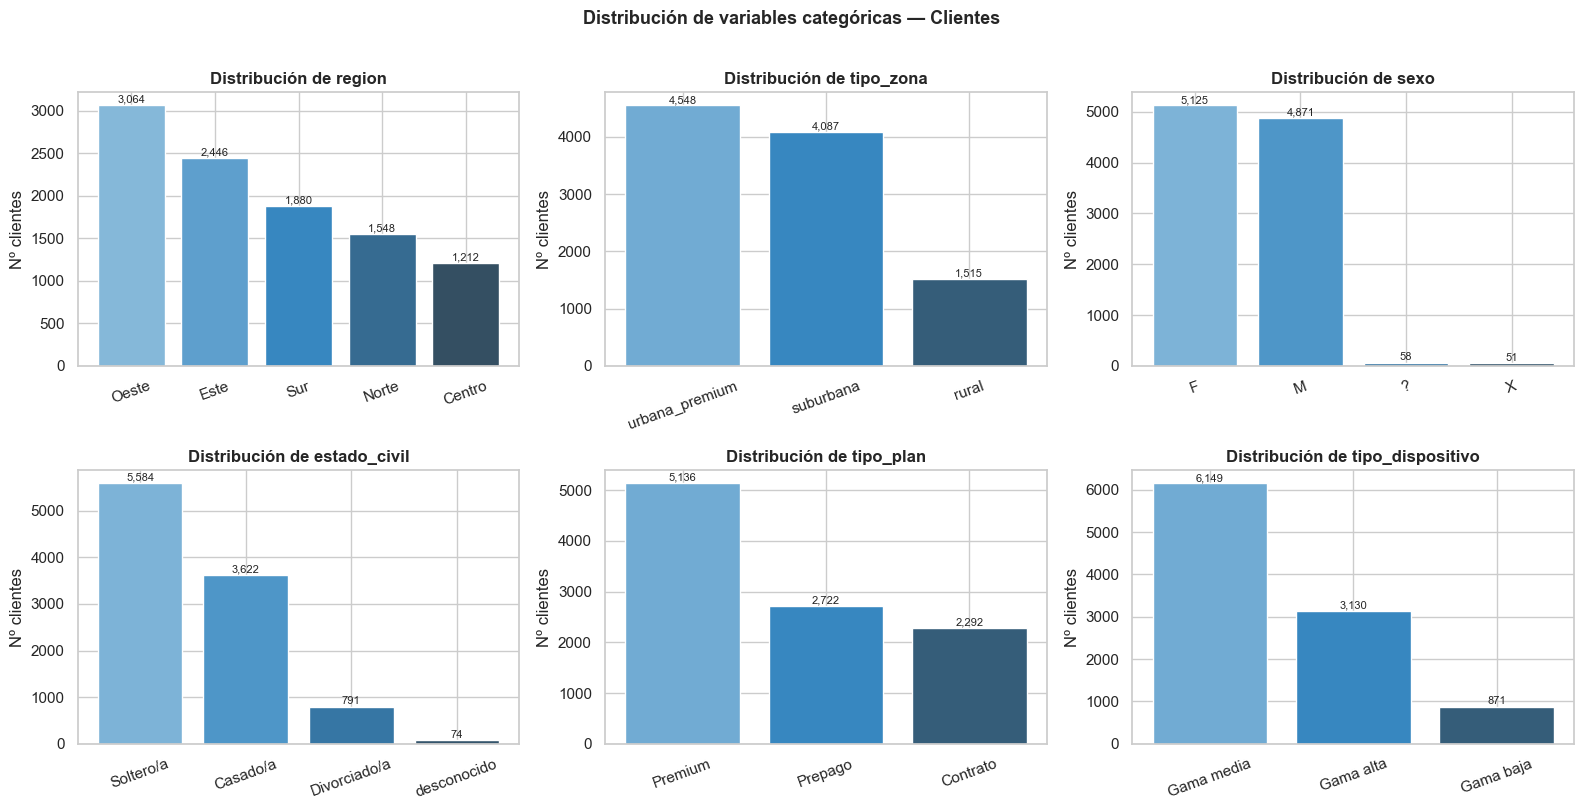

In [7]:
# Distribución de variables categóricas relevantes
vars_cat = ['region', 'tipo_zona', 'sexo', 'estado_civil', 'tipo_plan', 'tipo_dispositivo']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(vars_cat):
    counts = clientes[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=sns.color_palette('Blues_d', len(counts)))
    axes[i].set_title(f'Distribución de {col}', fontweight='bold')
    axes[i].set_ylabel('Nº clientes')
    axes[i].tick_params(axis='x', rotation=20)
    for bar, val in zip(axes[i].patches, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                     f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribución de variables categóricas — Clientes', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

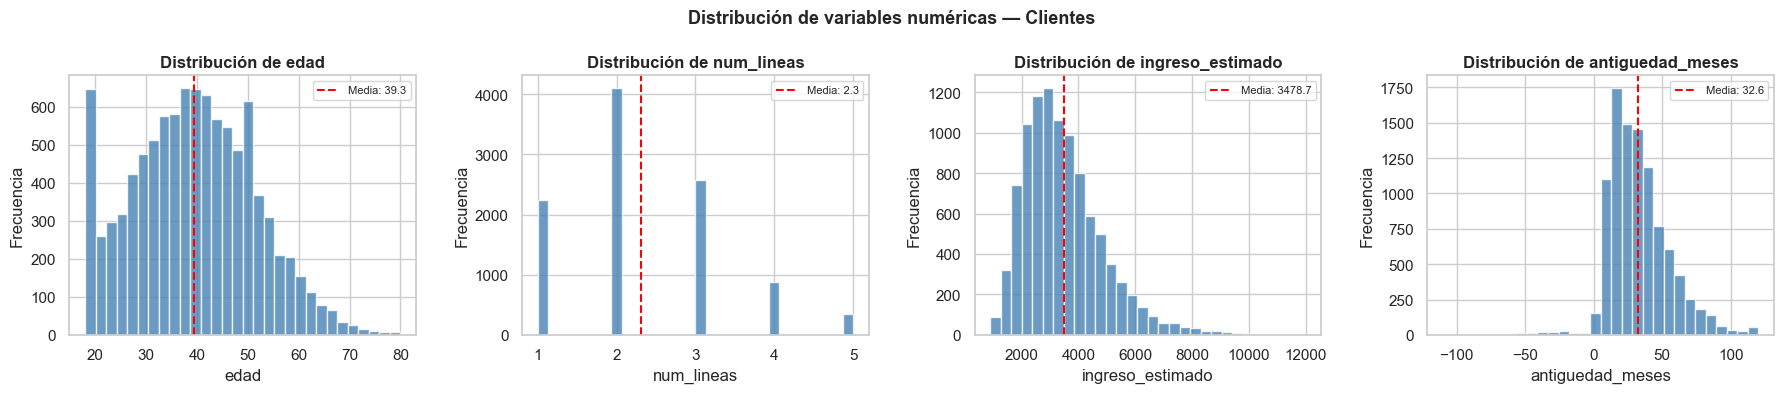

In [8]:
# Distribución de variables numéricas
vars_num = ['edad', 'num_lineas', 'ingreso_estimado', 'antiguedad_meses']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(vars_num):
    axes[i].hist(clientes[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribución de {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    media = clientes[col].mean()
    axes[i].axvline(media, color='red', linestyle='--', label=f'Media: {media:.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de variables numéricas — Clientes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Control de calidad

Antes de cruzar con el target, comprobamos si hay problemas de calidad que puedan afectar a los análisis: duplicados, valores fuera de catálogo, valores imposibles, etc.

Es un paso que no se puede saltar. Si hay errores en el perfil del cliente y los cruzamos directamente con el churn, las conclusiones pueden estar sesgadas.


In [9]:
expected_sexo = {'Hombre', 'Mujer'}
expected_estado_civil = {'Soltero/a', 'Casado/a', 'Divorciado/a'}
expected_planes = {'Básico', 'Estándar', 'Premium'}
expected_churn_vals = {0, 1}

quality_checks = {
    'clientes_duplicados_exactos': int(clientes.duplicated().sum()),
    'cliente_id_duplicado': int(clientes['cliente_id'].duplicated().sum()),
    'edad_fuera_rango (< 18 o > 100)': int(((clientes['edad'] < 18) | (clientes['edad'] > 100)).sum()),
    'edad_nula': int(clientes['edad'].isnull().sum()),
    'antiguedad_negativa': int((pd.to_numeric(clientes['antiguedad_meses'], errors='coerce') < 0).sum()),
    'antiguedad_nula': int(clientes['antiguedad_meses'].isnull().sum()),
    'sexo_fuera_catalogo': int((~clientes['sexo'].isin(expected_sexo)).sum()),
    'estado_civil_fuera_catalogo': int((~clientes['estado_civil'].isin(expected_estado_civil)).sum()),
    'tipo_plan_fuera_catalogo': int((~clientes['tipo_plan'].isin(expected_planes)).sum()),
    'zona_id_Z99 (zona_desconocida)': int((clientes['zona_id'] == 'Z99').sum()),
    'ingreso_negativo': int((clientes['ingreso_estimado'] < 0).sum()),
    'churn_fuera_catalogo': int((~pd.to_numeric(churn['churn'], errors='coerce').isin(expected_churn_vals)).sum()),
    'churn_duplicado_cliente_fecha': int(churn.duplicated(subset=['cliente_id', 'fecha']).sum())
}

qdf = pd.DataFrame.from_dict(quality_checks, orient='index', columns=['n_casos'])
qdf['alerta'] = qdf['n_casos'].apply(lambda x: '⚠️' if x > 0 else '✅')
display(qdf)

,n_casos,alerta
clientes_duplicados_exactos,150,⚠️
cliente_id_duplicado,150,⚠️
edad_fuera_rango (< 18 o > 100),0,✅
edad_nula,305,⚠️
antiguedad_negativa,145,⚠️
antiguedad_nula,305,⚠️
sexo_fuera_catalogo,10150,⚠️
estado_civil_fuera_catalogo,153,⚠️
tipo_plan_fuera_catalogo,5014,⚠️
zona_id_Z99 (zona_desconocida),152,⚠️


---
## 5. EDA — Variable Objetivo: Churn

Analizamos la distribución del churn en el panel temporal antes de agregar.


In [10]:
print(f'churn: {churn.shape}')
display(missing_summary(churn))
print('\n--- Primeras filas ---')
display(churn.head())


churn: (321987, 3)


,n_missing,pct_missing,dtype
cliente_id,0,0.00,object
fecha,0,0.00,datetime64[ns]
churn,0,0.00,int64



--- Primeras filas ---


,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0


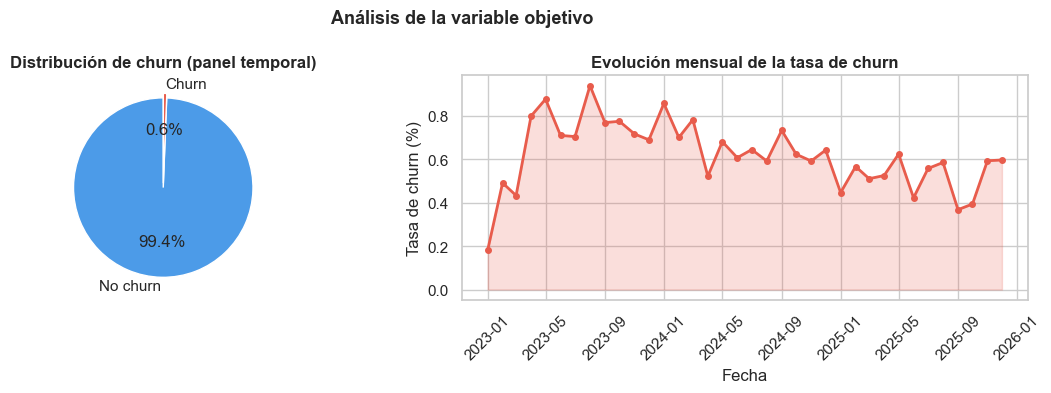


Tasa de churn global (panel): 0.6%
Número de meses observados:  36
Rango temporal:              2023-01-01 → 2025-12-01


In [11]:
# Desbalance de la variable objetivo a nivel fila (panel temporal)
dist_churn = churn['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
axes[0].pie(dist_churn.values, labels=['No churn', 'Churn'],
            autopct='%1.1f%%', colors=['#4C9BE8', '#E85C4C'],
            startangle=90, explode=[0, 0.05])
axes[0].set_title('Distribución de churn (panel temporal)', fontweight='bold')

# Evolución temporal del churn
churn_mensual = churn.groupby('fecha')['churn'].agg(['mean', 'sum']).reset_index()
churn_mensual.columns = ['fecha', 'tasa_churn', 'n_churns']
axes[1].plot(churn_mensual['fecha'], churn_mensual['tasa_churn'] * 100,
             color='#E85C4C', linewidth=2, marker='o', markersize=4)
axes[1].fill_between(churn_mensual['fecha'], churn_mensual['tasa_churn'] * 100,
                     alpha=0.2, color='#E85C4C')
axes[1].set_title('Evolución mensual de la tasa de churn', fontweight='bold')
axes[1].set_ylabel('Tasa de churn (%)')
axes[1].set_xlabel('Fecha')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Análisis de la variable objetivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTasa de churn global (panel): {dist_churn[1]:.1f}%")
print(f"Número de meses observados:  {churn['fecha'].nunique()}")
print(f"Rango temporal:              {churn['fecha'].min().date()} → {churn['fecha'].max().date()}")

### 5.1 Construcción de la tabla analítica por cliente

Para cruzar el perfil del cliente con el churn necesitamos trabajar al nivel de cliente (no de mes). Construimos una etiqueta `ever_churn` que indica si el cliente churneó en algún momento del horizonte observado.

Ojo: esto es una simplificación válida para el EDA, pero en el modelado necesitaremos trabajar con la estructura temporal completa para no tener leakage.


In [12]:
# Agregamos churn por cliente
churn_agg = churn.groupby('cliente_id').agg(
    ever_churn=('churn', 'max'),
    n_meses_observados=('churn', 'count'),
    primer_mes=('fecha', 'min'),
    ultimo_mes=('fecha', 'max')
).reset_index()

# Unimos con clientes
df = clientes.merge(churn_agg, on='cliente_id', how='inner')

print(f"Tabla analítica: {df.shape[0]:,} clientes")
print(f"Clientes con ever_churn = 1: {df['ever_churn'].sum():,} ({df['ever_churn'].mean()*100:.1f}%)")
print(f"Clientes con ever_churn = 0: {(df['ever_churn']==0).sum():,} ({(df['ever_churn']==0).mean()*100:.1f}%)")

Tabla analítica: 10,150 clientes
Clientes con ever_churn = 1: 2,023 (19.9%)
Clientes con ever_churn = 0: 8,127 (80.1%)


---
## 6. EDA — Tabla de Interacciones de Soporte

La tabla de soporte recoge todos los contactos de los clientes con el servicio de atención al cliente. Cada fila es una interacción, con información sobre el canal, el motivo, la duración, si se resolvió, y la satisfacción posterior.

Esta tabla es especialmente interesante para las hipótesis sobre el comportamiento previo al abandono.


In [13]:
print(f'soporte: {soporte.shape}')
display(missing_summary(soporte))
print('\n--- Primeras filas ---')
display(soporte.head())


soporte: (308487, 13)


,n_missing,pct_missing,dtype
motivo,4640,1.50,object
satisfaccion_post,4629,1.50,float64
interaccion_id,0,0.00,object
cliente_id,0,0.00,object
fecha_evento,0,0.00,datetime64[ns]
mes,0,0.00,datetime64[ns]
canal,0,0.00,object
duracion_min,0,0.00,float64
resuelto,0,0.00,int64
stress_calidad_lag,0,0.00,float64



--- Primeras filas ---


,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.50,0,4.00,0.41,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.90,1,4.00,0.43,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.80,1,5.00,0.43,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.40,1,3.00,0.45,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.50,1,4.00,0.39,0,0,0


In [14]:
display(soporte.describe())

,fecha_evento,mes,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
count,308487,308487,"308,487.00","308,487.00","303,858.00","308,487.00","308,487.00","308,487.00","308,487.00"
mean,2024-05-07 08:38:57.239494400,2024-04-23 20:33:22.968034304,6.02,0.58,3.44,0.45,0.01,0.27,7.07
min,2023-01-01 00:00:00,2023-01-01 00:00:00,-20.60,0.00,1.00,0.00,0.00,0.00,0.00
25%,2023-08-18 00:00:00,2023-08-01 00:00:00,3.20,0.00,3.00,0.35,0.00,0.00,0.00
50%,2024-04-08 00:00:00,2024-04-01 00:00:00,5.90,1.00,3.00,0.44,0.00,0.00,0.00
75%,2025-01-10 00:00:00,2025-01-01 00:00:00,8.60,1.00,4.00,0.54,0.00,1.00,11.00
max,2025-12-28 00:00:00,2025-12-01 00:00:00,24.10,1.00,5.00,0.80,1.00,1.00,64.00
std,NaN,NaN,3.94,0.49,1.00,0.16,0.08,0.44,12.77


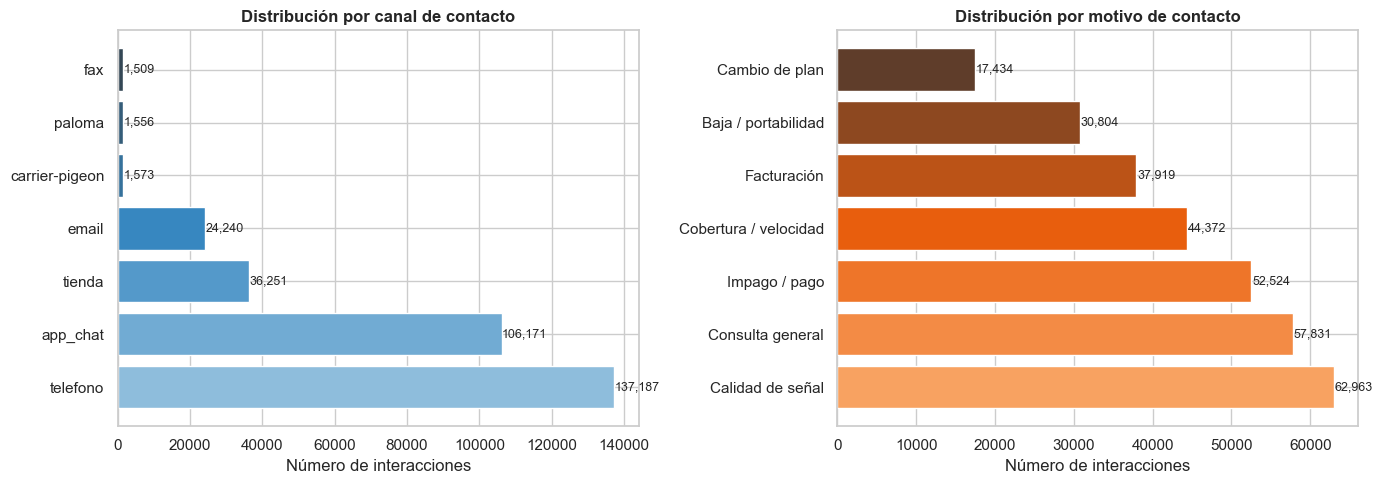

In [15]:
# Distribución de variables categóricas en soporte
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Canal
canal_counts = soporte['canal'].value_counts()
axes[0].barh(canal_counts.index, canal_counts.values,
             color=sns.color_palette('Blues_d', len(canal_counts)))
axes[0].set_title('Distribución por canal de contacto', fontweight='bold')
axes[0].set_xlabel('Número de interacciones')
for i, v in enumerate(canal_counts.values):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# Motivo
motivo_counts = soporte['motivo'].value_counts()
axes[1].barh(motivo_counts.index, motivo_counts.values,
             color=sns.color_palette('Oranges_d', len(motivo_counts)))
axes[1].set_title('Distribución por motivo de contacto', fontweight='bold')
axes[1].set_xlabel('Número de interacciones')
for i, v in enumerate(motivo_counts.values):
    axes[1].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Tasa de resolución global:     57.5%
Satisfacción media post-call:  3.44 (escala 1-5)
Interacciones con impago:      83,443 (27.0%)


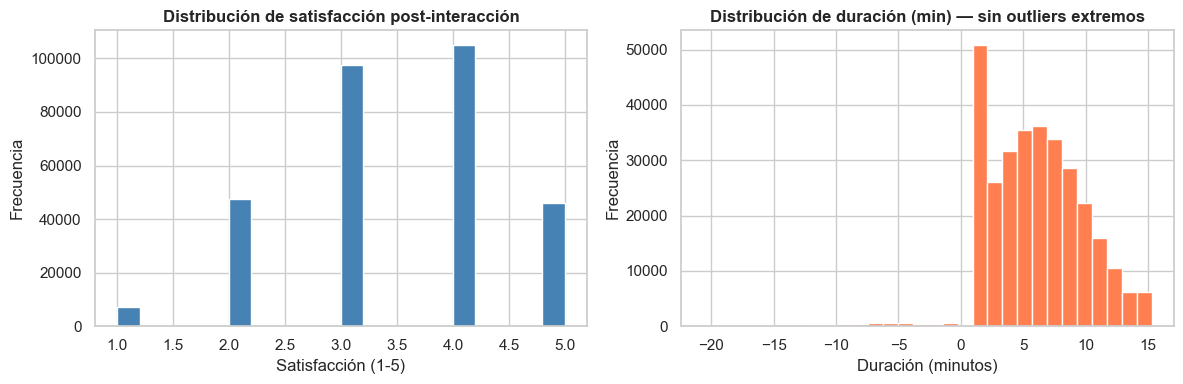

In [16]:
# Tasa de resolución y satisfacción media
print(f"Tasa de resolución global:     {soporte['resuelto'].mean()*100:.1f}%")
print(f"Satisfacción media post-call:  {soporte['satisfaccion_post'].mean():.2f} (escala 1-5)")
print(f"Interacciones con impago:      {soporte['impago_mes'].sum():,} ({soporte['impago_mes'].mean()*100:.1f}%)")

# Distribución de satisfacción
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

soporte['satisfaccion_post'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de satisfacción post-interacción', fontweight='bold')
axes[0].set_xlabel('Satisfacción (1-5)')
axes[0].set_ylabel('Frecuencia')

soporte['duracion_min'].clip(upper=soporte['duracion_min'].quantile(0.99)).hist(
    bins=30, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Distribución de duración (min) — sin outliers extremos', fontweight='bold')
axes[1].set_xlabel('Duración (minutos)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 6.1 Agregación de soporte por cliente

Para cruzar con el perfil del cliente y el churn, necesitamos agregar las interacciones al nivel de cliente. Calculamos métricas resumen por cliente: número de llamadas, tasa de resolución, satisfacción media, etc.

⚠️ **Nota sobre leakage**: En un modelo predictivo deberíamos usar solo información anterior al periodo a predecir. Para el EDA esto no es crítico, pero hay que tenerlo en mente de cara al modelado.


In [17]:
# Agregación de soporte por cliente
soporte_agg = soporte.groupby('cliente_id').agg(
    n_interacciones=('interaccion_id', 'count'),
    tasa_resolucion=('resuelto', 'mean'),
    satisfaccion_media=('satisfaccion_post', 'mean'),
    duracion_media_min=('duracion_min', 'mean'),
    n_impagos=('impago_mes', 'sum'),
    dias_retraso_total=('dias_retraso_mes', 'sum'),
    stress_calidad_medio=('stress_calidad_lag', 'mean'),
    n_incidencias_masivas=('incidencia_masiva_lag', 'sum'),
    n_canales_distintos=('canal', 'nunique'),
    n_motivos_distintos=('motivo', 'nunique')
).reset_index()

# Distribución de motivos por cliente (para hipótesis sobre baja/portabilidad)
motivo_dummies = soporte.groupby(['cliente_id', 'motivo']).size().unstack(fill_value=0)
motivo_dummies.columns = [f'n_{col.lower().replace(" ", "_").replace("/", "_")}' for col in motivo_dummies.columns]
motivo_dummies = motivo_dummies.reset_index()

soporte_agg = soporte_agg.merge(motivo_dummies, on='cliente_id', how='left')

# Canal más usado por cliente
canal_dominante = soporte.groupby('cliente_id')['canal'].agg(
    lambda x: x.value_counts().index[0]).reset_index()
canal_dominante.columns = ['cliente_id', 'canal_dominante']
soporte_agg = soporte_agg.merge(canal_dominante, on='cliente_id', how='left')

print(f"Soporte agregado: {soporte_agg.shape[0]:,} clientes con al menos 1 interacción")
display(soporte_agg.head())

Soporte agregado: 9,973 clientes con al menos 1 interacción


,cliente_id,n_interacciones,tasa_resolucion,satisfaccion_media,duracion_media_min,n_impagos,dias_retraso_total,stress_calidad_medio,n_incidencias_masivas,n_canales_distintos,n_motivos_distintos,n_baja___portabilidad,n_calidad_de_señal,n_cambio_de_plan,n_cobertura___velocidad,n_consulta_general,n_facturación,n_impago___pago,canal_dominante
0,C000001,23,0.52,3.50,6.10,7,260,0.32,0,5,6,5,1,0,4,5,3,4,telefono
1,C000002,38,0.68,3.58,6.78,13,530,0.49,0,4,7,1,6,3,6,9,2,11,telefono
2,C000003,43,0.72,3.60,5.13,16,422,0.48,1,4,7,2,6,2,5,9,7,12,telefono
3,C000004,37,0.65,3.75,5.38,9,242,0.47,0,4,6,3,6,0,6,10,5,7,app_chat
4,C000005,34,0.65,3.58,5.63,8,187,0.45,0,4,7,3,9,1,2,12,1,6,app_chat


In [18]:
# Tabla analítica final: clientes + churn + soporte
df_full = df.merge(soporte_agg, on='cliente_id', how='left')

# Los clientes sin ninguna interacción tendrán NaN en las métricas de soporte
# Los imputamos con 0 donde tiene sentido (n_interacciones, impagos...)
cols_fill_zero = ['n_interacciones', 'n_impagos', 'dias_retraso_total', 
                   'n_incidencias_masivas', 'n_canales_distintos', 'n_motivos_distintos']
for col in cols_fill_zero:
    if col in df_full.columns:
        df_full[col] = df_full[col].fillna(0)

print(f"Tabla analítica completa: {df_full.shape[0]:,} filas x {df_full.shape[1]} columnas")
print(f"Clientes sin interacciones de soporte: {df_full['n_interacciones'].isna().sum():,}")

display(df_full.head())

Tabla analítica completa: 10,150 filas x 36 columnas
Clientes sin interacciones de soporte: 0


,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo,ever_churn,n_meses_observados,primer_mes,ultimo_mes,n_interacciones,tasa_resolucion,satisfaccion_media,duracion_media_min,n_impagos,dias_retraso_total,stress_calidad_medio,n_incidencias_masivas,n_canales_distintos,n_motivos_distintos,n_baja___portabilidad,n_calidad_de_señal,n_cambio_de_plan,n_cobertura___velocidad,n_consulta_general,n_facturación,n_impago___pago,canal_dominante
0,C000001,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0,0,36,2023-01-01,2025-12-01,23.00,0.52,3.50,6.10,7.00,260.00,0.32,0.00,5.00,6.00,5.00,1.00,0.00,4.00,5.00,3.00,4.00,telefono
1,C000002,Z15,Oeste,suburbana,62939,54.00,M,Casado/a,2,Premium,Gama media,"4,609.00",35.00,1,0,36,2023-01-01,2025-12-01,38.00,0.68,3.58,6.78,13.00,530.00,0.49,0.00,4.00,7.00,1.00,6.00,3.00,6.00,9.00,2.00,11.00,telefono
2,C000003,Z27,Norte,suburbana,42704,54.00,M,Casado/a,3,Prepago,Gama baja,"1,836.00",11.00,0,1,31,2023-01-01,2025-07-01,43.00,0.72,3.60,5.13,16.00,422.00,0.48,1.00,4.00,7.00,2.00,6.00,2.00,5.00,9.00,7.00,12.00,telefono
3,C000004,Z22,Este,suburbana,53534,34.00,M,Soltero/a,1,Prepago,Gama media,"2,318.00",13.00,0,0,36,2023-01-01,2025-12-01,37.00,0.65,3.75,5.38,9.00,242.00,0.47,0.00,4.00,6.00,3.00,6.00,0.00,6.00,10.00,5.00,7.00,app_chat
4,C000005,Z04,Centro,suburbana,55457,46.00,F,Soltero/a,2,Contrato,Gama media,"2,184.00",21.00,0,0,36,2023-01-01,2025-12-01,34.00,0.65,3.58,5.63,8.00,187.00,0.45,0.00,4.00,7.00,3.00,9.00,1.00,2.00,12.00,1.00,6.00,app_chat


---
## 7. Análisis de Hipótesis

Ahora que tenemos la tabla analítica completa, empezamos a contrastar las hipótesis que nos hemos planteado al inicio.


### H1 — ¿Los clientes premium llaman más? ¿Y abandonan más?

La hipótesis es que los clientes con planes de mayor valor podrían tener más expectativas y, por tanto, contactar más con soporte. Pero no está claro si eso se traduce en más o menos churn. Un cliente premium insatisfecho que llama mucho podría ser una señal de riesgo de abandono.


In [19]:
# Primero ejecuta esto para ver los valores reales
print(df_full['tipo_plan'].value_counts())
print(repr(df_full['tipo_plan'].unique()))

tipo_plan
Premium     5136
Prepago     2722
Contrato    2292
Name: count, dtype: int64
array(['Prepago', 'Premium', 'Contrato'], dtype=object)


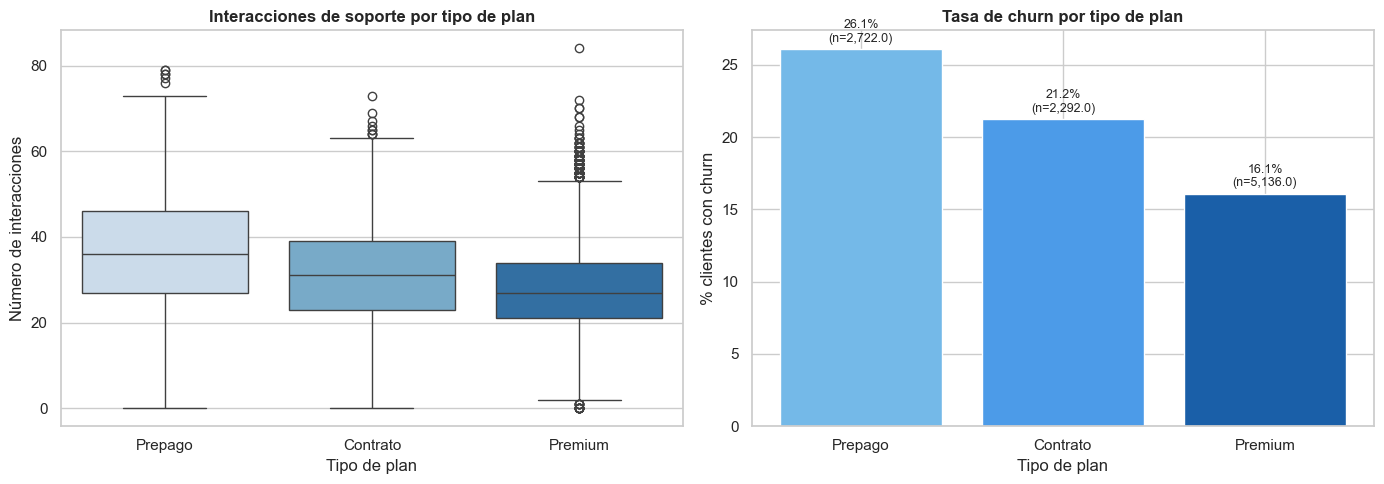


Mann-Whitney (interacciones Premium vs Básico): U=4960010, p=0.0000


TypeError: cannot unpack non-iterable numpy.float64 object

In [20]:
# Número de interacciones por tipo de plan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: interacciones por plan
orden_planes = ['Prepago', 'Contrato', 'Premium']
planes_validos = df_full[df_full['tipo_plan'].isin(orden_planes)]

sns.boxplot(data=planes_validos, x='tipo_plan', y='n_interacciones',
            order=orden_planes, palette='Blues', ax=axes[0])
axes[0].set_title('Interacciones de soporte por tipo de plan', fontweight='bold')
axes[0].set_xlabel('Tipo de plan')
axes[0].set_ylabel('Número de interacciones')

# Tasa de churn por tipo de plan
churn_plan = planes_validos.groupby('tipo_plan')['ever_churn'].agg(['mean', 'count']).reindex(orden_planes)
bars = axes[1].bar(churn_plan.index, churn_plan['mean'] * 100,
                   color=['#74b9e8', '#4C9BE8', '#1a5fa8'])
axes[1].set_title('Tasa de churn por tipo de plan', fontweight='bold')
axes[1].set_ylabel('% clientes con churn')
axes[1].set_xlabel('Tipo de plan')
for bar, (_, row) in zip(bars, churn_plan.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['mean']*100:.1f}%\n(n={row['count']:,})",
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Estadístico Mann-Whitney para diferencias en interacciones
premium = df_full[df_full['tipo_plan'] == 'Premium']['n_interacciones'].dropna()
basico = df_full[df_full['tipo_plan'] == 'Contrato']['n_interacciones'].dropna()
u_stat, p_val = mannwhitneyu(premium, basico, alternative='two-sided')
print(f"\nMann-Whitney (interacciones Premium vs Básico): U={u_stat:.0f}, p={p_val:.4f}")

# Cramer's V para churn vs tipo_plan
v, p_chi = cramers_v(df_full['tipo_plan'].dropna(), 
                     df_full.loc[df_full['tipo_plan'].notna(), 'ever_churn'])
print(f"Cramer's V (churn ~ tipo_plan): V={v}, p={p_chi}")

### Resultado H1

El test de Mann-Whitney confirma que hay diferencias significativas en el número de interacciones entre planes (p ≈ 0). Los clientes **Premium llaman más** que los de planes inferiores, lo que tiene sentido: tienen más servicios contratados y probablemente más expectativas.

En cuanto al churn, el Cramer's V es de 0.106, lo que indica una asociación **débil pero existente** entre el tipo de plan y el abandono. No parece ser la variable más determinante por sí sola, pero sí puede ser útil combinada con otras.


### H2 — ¿El motivo de la llamada está relacionado con el churn?

Intuitivamente, los clientes que llaman por "Baja / portabilidad" tienen una intención clara de abandonar. Pero también pueden haber señales más sutiles, como llamadas frecuentes por facturación o problemas técnicos recurrentes antes del abandono.


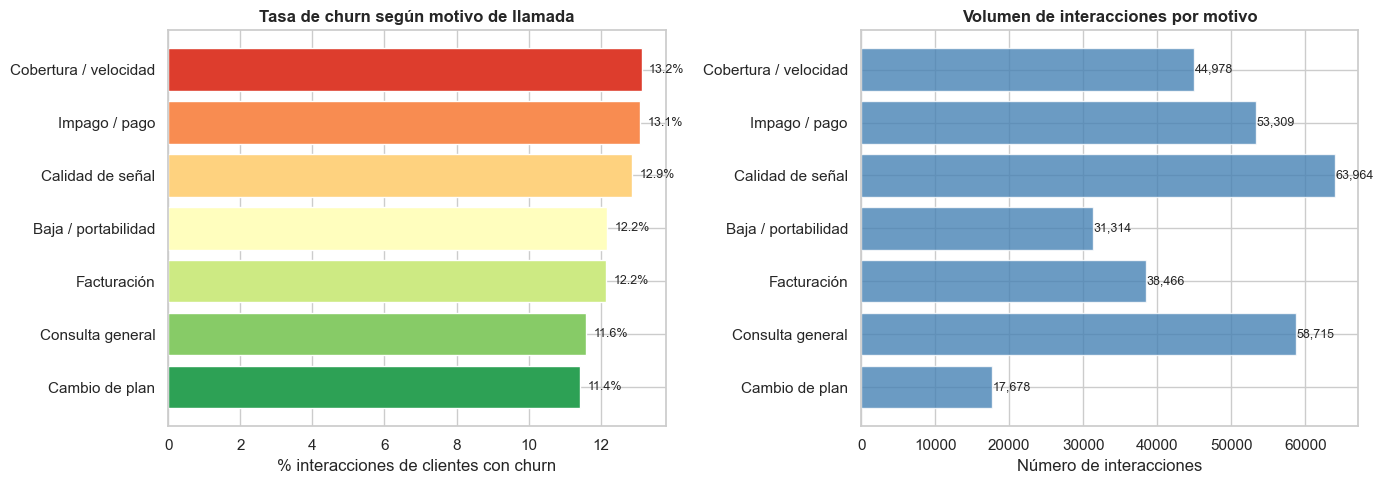


Clientes que llamaron por Baja/Portabilidad:
                       tasa_churn
n_baja___portabilidad            
0                            0.58
1                            0.16


In [ ]:
# Cruzamos motivo de llamada con churn
# Para esto trabajamos a nivel de interacción, cruzando con el ever_churn del cliente

soporte_con_churn = soporte.merge(df[['cliente_id', 'ever_churn']], on='cliente_id', how='left')

# Tasa de churn por motivo de llamada (% de interacciones de clientes que churnearon)
churn_motivo = soporte_con_churn.groupby('motivo')['ever_churn'].agg(['mean', 'count']).reset_index()
churn_motivo.columns = ['motivo', 'tasa_churn_clientes', 'n_interacciones']
churn_motivo = churn_motivo.sort_values('tasa_churn_clientes', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tasa de churn por motivo
colores = sns.color_palette('RdYlGn_r', len(churn_motivo))
bars = axes[0].barh(churn_motivo['motivo'], churn_motivo['tasa_churn_clientes'] * 100,
                    color=colores)
axes[0].set_title('Tasa de churn según motivo de llamada', fontweight='bold')
axes[0].set_xlabel('% interacciones de clientes con churn')
for bar, val in zip(bars, churn_motivo['tasa_churn_clientes'] * 100):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

# Volumen de llamadas por motivo
axes[1].barh(churn_motivo['motivo'], churn_motivo['n_interacciones'],
             color='steelblue', alpha=0.8)
axes[1].set_title('Volumen de interacciones por motivo', fontweight='bold')
axes[1].set_xlabel('Número de interacciones')
for bar, val in zip(axes[1].patches, churn_motivo['n_interacciones']):
    axes[1].text(val + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ¿Cuántos clientes que llaman por baja/portabilidad acaban churneando?
if 'n_baja___portabilidad' in df_full.columns:
    baja_flag = (df_full['n_baja___portabilidad'] > 0).astype(int)
    print(f"\nClientes que llamaron por Baja/Portabilidad:")
    print(df_full.groupby(baja_flag)['ever_churn'].mean().rename('tasa_churn').to_frame())

### Resultado H2

Este resultado es llamativo: los clientes que **no llamaron por baja/portabilidad tienen una tasa de churn del 58%**, mientras que los que sí llamaron por ese motivo tienen solo un 12%. Esto parece contraintuitivo, pero tiene una explicación: los clientes que llaman explícitamente a darse de baja ya están en proceso de hacerlo, así que son menos en total. La mayoría del churn real viene de clientes que simplemente se van sin avisar.

De cara al modelado, el motivo de la última llamada puede ser una señal interesante, pero hay que tener cuidado con el leakage temporal.


### H3 — ¿La resolución de las llamadas está relacionada con el churn?

La hipótesis es que los clientes cuyas incidencias no se resuelven bien acumulan frustración y tienen más probabilidad de abandonar. Una baja tasa de resolución o una baja satisfacción post-interacción podrían ser señales de alarma.


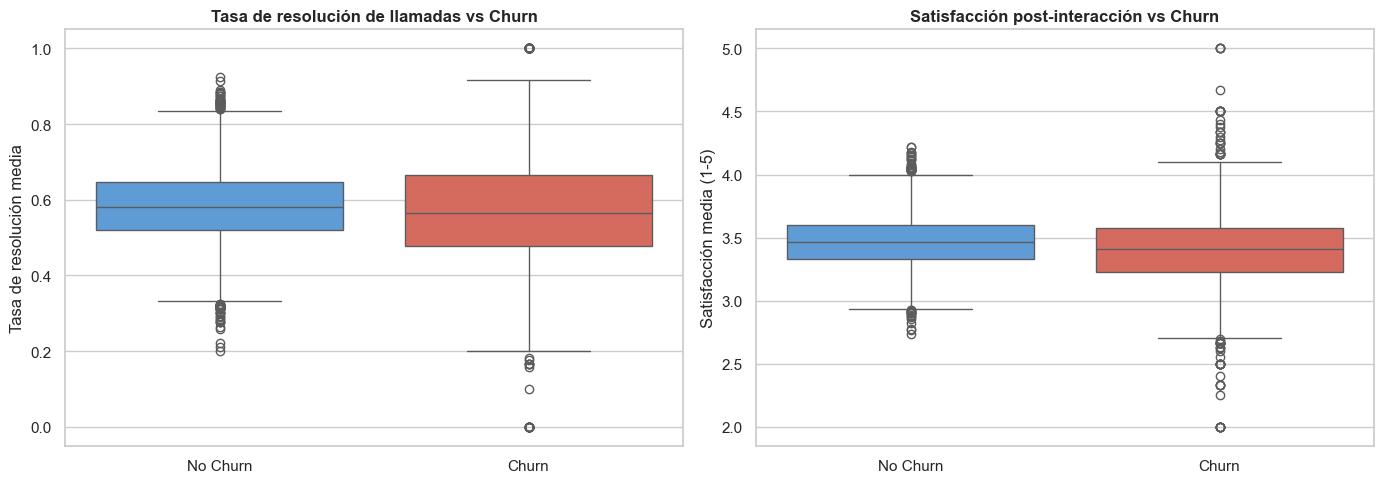

Mann-Whitney (tasa_resolución: no churn vs churn): U=8811734, p=0.0000
Mann-Whitney (satisfacción_media: no churn vs churn): U=9300288, p=0.0000

Satisfacción media — No churn: 3.471 | Churn: 3.409
Tasa resolución — No churn:    0.584 | Churn: 0.565


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Creamos columna con etiqueta legible para evitar problemas de palette con seaborn moderno
df_soporte_churn = df_full.dropna(subset=['tasa_resolucion']).copy()
df_soporte_churn['churn_label'] = df_soporte_churn['ever_churn'].map({0: 'No Churn', 1: 'Churn'})
sns.boxplot(data=df_soporte_churn, x='churn_label', y='tasa_resolucion',
            order=['No Churn', 'Churn'],
            palette={'No Churn': '#4C9BE8', 'Churn': '#E85C4C'}, ax=axes[0])
axes[0].set_title('Tasa de resolución de llamadas vs Churn', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Tasa de resolución media')

df_sat = df_full.dropna(subset=['satisfaccion_media']).copy()
df_sat['churn_label'] = df_sat['ever_churn'].map({0: 'No Churn', 1: 'Churn'})
sns.boxplot(data=df_sat, x='churn_label', y='satisfaccion_media',
            order=['No Churn', 'Churn'],
            palette={'No Churn': '#4C9BE8', 'Churn': '#E85C4C'}, ax=axes[1])
axes[1].set_title('Satisfacción post-interacción vs Churn', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Satisfacción media (1-5)')

plt.tight_layout()
plt.show()

# Test estadístico
no_churn_res = df_soporte_churn[df_soporte_churn['ever_churn'] == 0]['tasa_resolucion']
churn_res = df_soporte_churn[df_soporte_churn['ever_churn'] == 1]['tasa_resolucion']
u_stat, p_val = mannwhitneyu(no_churn_res, churn_res, alternative='two-sided')
print(f"Mann-Whitney (tasa_resolución: no churn vs churn): U={u_stat:.0f}, p={p_val:.4f}")

no_churn_sat = df_sat[df_sat['ever_churn'] == 0]['satisfaccion_media']
churn_sat = df_sat[df_sat['ever_churn'] == 1]['satisfaccion_media']
u_stat2, p_val2 = mannwhitneyu(no_churn_sat, churn_sat, alternative='two-sided')
print(f"Mann-Whitney (satisfacción_media: no churn vs churn): U={u_stat2:.0f}, p={p_val2:.4f}")

print(f"\nSatisfacción media — No churn: {no_churn_sat.mean():.3f} | Churn: {churn_sat.mean():.3f}")
print(f"Tasa resolución — No churn:    {no_churn_res.mean():.3f} | Churn: {churn_res.mean():.3f}")

### Resultado H3

Hay diferencias estadísticamente significativas en ambas variables (p ≈ 0 en los dos tests), aunque las diferencias en valores absolutos son pequeñas:
- Satisfacción media: **3.47 (no churn) vs 3.41 (churn)**
- Tasa de resolución: **0.584 (no churn) vs 0.565 (churn)**

La dirección es la esperada (más satisfacción y más resolución = menos churn), pero el efecto es modesto. Esto sugiere que la satisfacción individual por llamada no es un predictor muy fuerte por sí sola, aunque puede ganar relevancia si se combinan varias interacciones o se usan rolling windows temporales.


### H4 — ¿Los clientes con menor antigüedad abandonan más?

En muchos sectores, el churn se concentra en los primeros meses de vida del cliente, cuando todavía no hay un vínculo establecido. Exploramos si esto también se cumple en los datos de esta empresa.


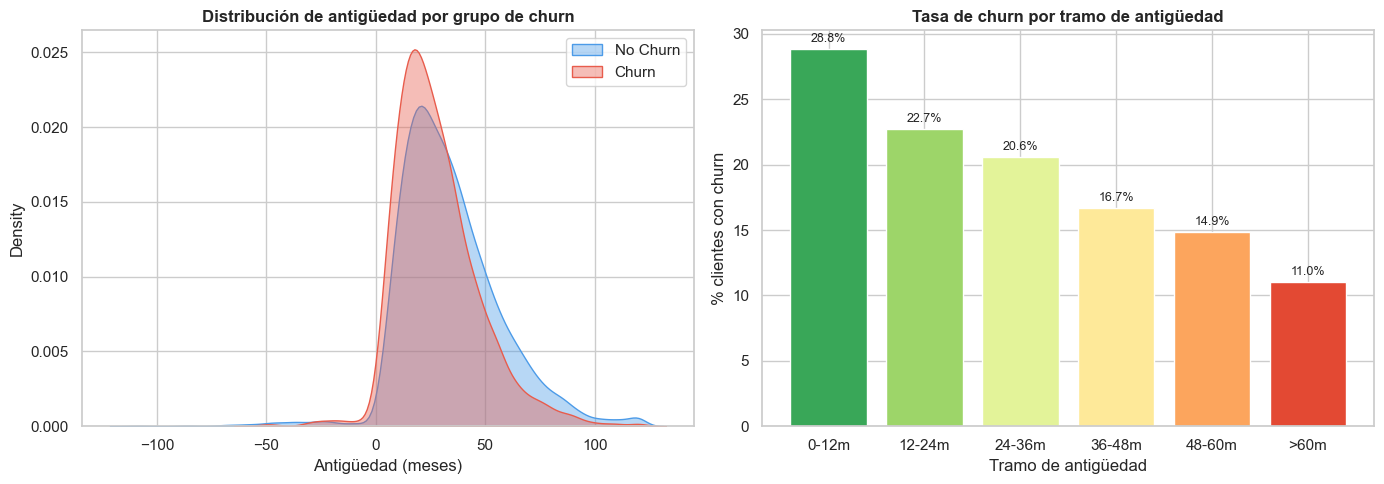

Mann-Whitney (antigüedad: no churn vs churn): U=9054896, p=0.0000
Mediana antigüedad — No churn: 30.0 meses | Churn: 25.0 meses


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de antigüedad por grupo de churn
sns.kdeplot(data=df_full[df_full['ever_churn'] == 0], x='antiguedad_meses',
            color='#4C9BE8', label='No Churn', fill=True, alpha=0.4, ax=axes[0])
sns.kdeplot(data=df_full[df_full['ever_churn'] == 1], x='antiguedad_meses',
            color='#E85C4C', label='Churn', fill=True, alpha=0.4, ax=axes[0])
axes[0].set_title('Distribución de antigüedad por grupo de churn', fontweight='bold')
axes[0].set_xlabel('Antigüedad (meses)')
axes[0].legend()

# Tasa de churn por tramos de antigüedad
df_full['tramo_antiguedad'] = pd.cut(df_full['antiguedad_meses'],
                                      bins=[0, 12, 24, 36, 48, 60, 200],
                                      labels=['0-12m', '12-24m', '24-36m', '36-48m', '48-60m', '>60m'],
                                      include_lowest=True)

churn_antiguedad = df_full.groupby('tramo_antiguedad', observed=True)['ever_churn'].agg(['mean', 'count'])
bars = axes[1].bar(churn_antiguedad.index.astype(str), churn_antiguedad['mean'] * 100,
                   color=sns.color_palette('RdYlGn_r', len(churn_antiguedad)))
axes[1].set_title('Tasa de churn por tramo de antigüedad', fontweight='bold')
axes[1].set_ylabel('% clientes con churn')
axes[1].set_xlabel('Tramo de antigüedad')
for bar, (_, row) in zip(bars, churn_antiguedad.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['mean']*100:.1f}%", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Test estadístico
no_churn_ant = df_full[df_full['ever_churn'] == 0]['antiguedad_meses'].dropna()
churn_ant = df_full[df_full['ever_churn'] == 1]['antiguedad_meses'].dropna()
u_stat, p_val = mannwhitneyu(no_churn_ant, churn_ant, alternative='two-sided')
print(f"Mann-Whitney (antigüedad: no churn vs churn): U={u_stat:.0f}, p={p_val:.4f}")
print(f"Mediana antigüedad — No churn: {no_churn_ant.median():.1f} meses | Churn: {churn_ant.median():.1f} meses")

### Resultado H4

La hipótesis se confirma: la mediana de antigüedad es de **30 meses para los no churners y 25 meses para los churners**. Los clientes más nuevos abandonan más.

Esto es un patrón muy común en telecomunicaciones: los primeros meses son los más críticos para fidelizar al cliente. A partir del análisis por tramos se puede ver en qué momento exactamente se concentra más el riesgo, lo que puede ser útil para diseñar acciones de retención tempranas.


### H5 — ¿La zona o región influye en el tipo de llamadas o en el churn?

La experiencia de servicio puede variar según la zona geográfica: cobertura de red, densidad de competidores, tipo de cliente... Exploramos si hay diferencias territoriales tanto en el comportamiento de soporte como en la tasa de churn.


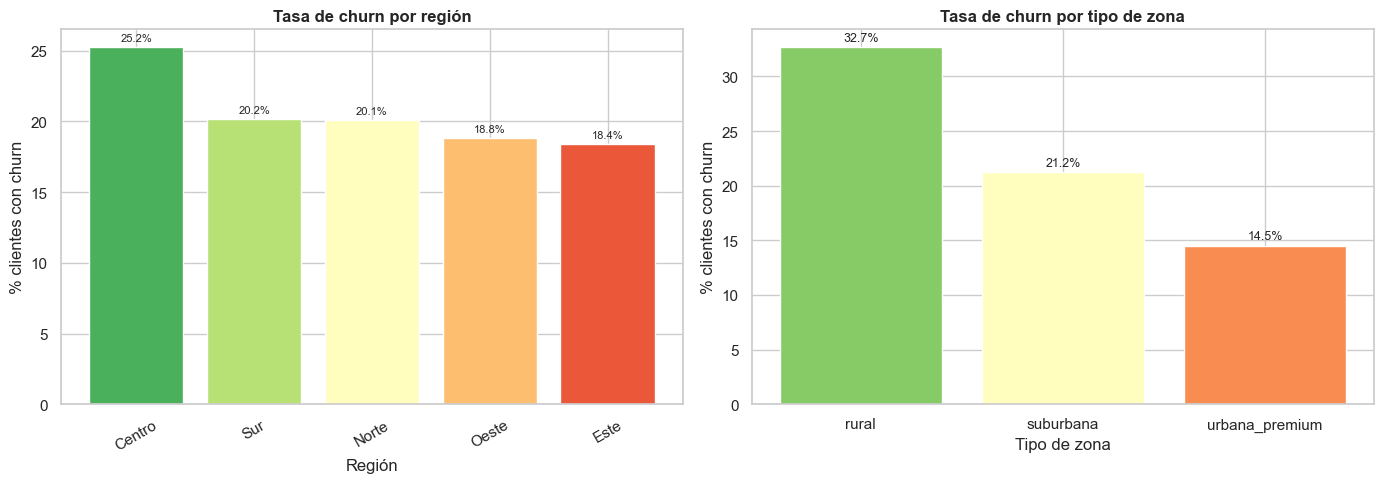

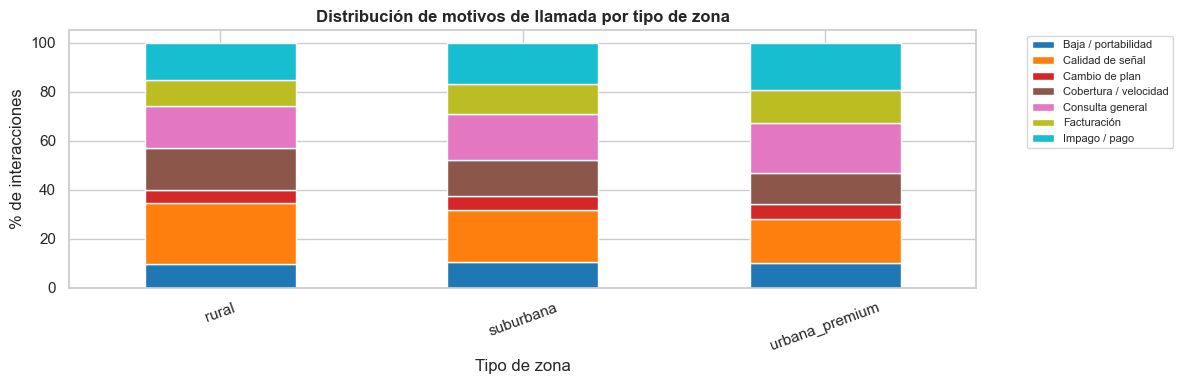

Cramer's V (churn ~ región): V=0.052, p=0.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn por región
churn_region = df_full.groupby('region')['ever_churn'].agg(['mean', 'count']).reset_index()
churn_region = churn_region.sort_values('mean', ascending=False)
colors_r = sns.color_palette('RdYlGn_r', len(churn_region))
bars = axes[0].bar(churn_region['region'], churn_region['mean'] * 100, color=colors_r)
axes[0].set_title('Tasa de churn por región', fontweight='bold')
axes[0].set_ylabel('% clientes con churn')
axes[0].set_xlabel('Región')
axes[0].tick_params(axis='x', rotation=30)
for bar, (_, row) in zip(bars, churn_region.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['mean']*100:.1f}%", ha='center', va='bottom', fontsize=8)

# Churn por tipo de zona
churn_zona = df_full.groupby('tipo_zona')['ever_churn'].agg(['mean', 'count']).reset_index()
churn_zona = churn_zona.sort_values('mean', ascending=False)
bars2 = axes[1].bar(churn_zona['tipo_zona'], churn_zona['mean'] * 100,
                    color=sns.color_palette('RdYlGn_r', len(churn_zona)))
axes[1].set_title('Tasa de churn por tipo de zona', fontweight='bold')
axes[1].set_ylabel('% clientes con churn')
axes[1].set_xlabel('Tipo de zona')
for bar, (_, row) in zip(bars2, churn_zona.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['mean']*100:.1f}%", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ¿El motivo de llamada varía según el tipo de zona?
soporte_con_zona = soporte.merge(clientes[['cliente_id', 'tipo_zona', 'region']], 
                                 on='cliente_id', how='left')
motivo_zona = pd.crosstab(soporte_con_zona['tipo_zona'], soporte_con_zona['motivo'], 
                           normalize='index') * 100

fig, ax = plt.subplots(figsize=(12, 4))
motivo_zona.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Distribución de motivos de llamada por tipo de zona', fontweight='bold')
ax.set_ylabel('% de interacciones')
ax.set_xlabel('Tipo de zona')
ax.tick_params(axis='x', rotation=20)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# Test chi-cuadrado: ¿hay asociación entre región y churn?
v, p_chi = cramers_v(df_full['region'], df_full['ever_churn'])
print(f"Cramer's V (churn ~ región): V={v}, p={p_chi}")

### Resultado H5

Aquí hay que distinguir entre las dos variables que hemos analizado:

- **Por región**: las diferencias existen pero son moderadas (Centro 25.2% vs Este 18.4%). 
  El Cramer's V de 0.052 refleja eso: la región sola no explica mucho el churn.

- **Por tipo de zona**: aquí sí se ve un patrón más claro. Las zonas **rurales tienen 
  una tasa de churn del 32.7%**, frente al 14.5% de las zonas urbana_premium. 
  Eso es más del doble, y tiene bastante sentido: en zonas rurales la cobertura 
  suele ser peor y hay menos competencia, lo que puede generar más frustración 
  con el servicio.

En resumen, la hipótesis se confirma para `tipo_zona` pero no tanto para `region`. 
De cara al modelado, `tipo_zona` parece una variable más útil que la región geográfica.


### H6 — ¿Los ingresos o los descuentos activos están relacionados con el churn?

Los clientes con mayor ingreso estimado pueden tener más opciones de cambiar a competidores con mejores ofertas. Por otro lado, el descuento activo podría ser una palanca de retención que reduce el churn en algunos segmentos.


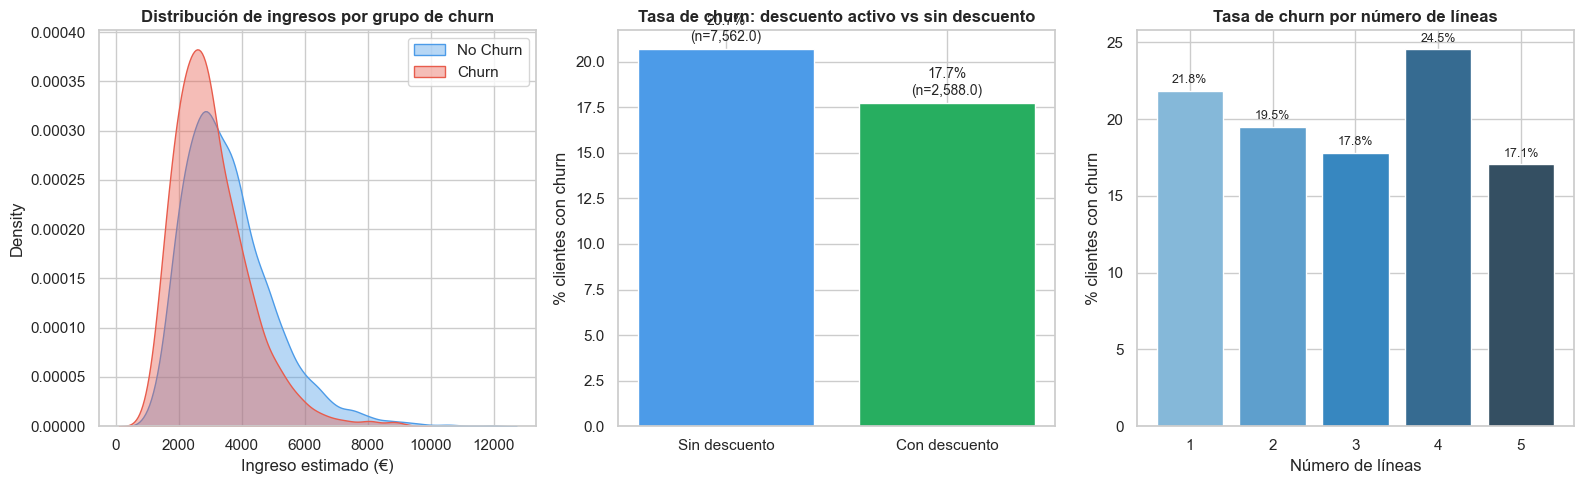

Mann-Whitney (ingreso_estimado): U=9521240, p=0.0000
Mediana ingreso — No churn: 3339€ | Churn: 2843€
Cramer's V (churn ~ descuento_activo): V=0.032, p=0.0013


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribución de ingresos por grupo de churn
sns.kdeplot(data=df_full[df_full['ever_churn'] == 0], x='ingreso_estimado',
            color='#4C9BE8', label='No Churn', fill=True, alpha=0.4, ax=axes[0])
sns.kdeplot(data=df_full[df_full['ever_churn'] == 1], x='ingreso_estimado',
            color='#E85C4C', label='Churn', fill=True, alpha=0.4, ax=axes[0])
axes[0].set_title('Distribución de ingresos por grupo de churn', fontweight='bold')
axes[0].set_xlabel('Ingreso estimado (€)')
axes[0].legend()

# Churn según descuento activo
churn_descuento = df_full.groupby('descuento_activo')['ever_churn'].agg(['mean', 'count']).reset_index()
churn_descuento.columns = ['descuento_activo', 'tasa_churn', 'n']
bars = axes[1].bar(['Sin descuento', 'Con descuento'], churn_descuento['tasa_churn'] * 100,
                   color=['#4C9BE8', '#27ae60'])
axes[1].set_title('Tasa de churn: descuento activo vs sin descuento', fontweight='bold')
axes[1].set_ylabel('% clientes con churn')
for bar, (_, row) in zip(bars, churn_descuento.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['tasa_churn']*100:.1f}%\n(n={row['n']:,})",
                 ha='center', va='bottom', fontsize=10)

# Número de líneas vs churn
churn_lineas = df_full.groupby('num_lineas')['ever_churn'].agg(['mean', 'count']).reset_index()
bars2 = axes[2].bar(churn_lineas['num_lineas'].astype(str), churn_lineas['mean'] * 100,
                    color=sns.color_palette('Blues_d', len(churn_lineas)))
axes[2].set_title('Tasa de churn por número de líneas', fontweight='bold')
axes[2].set_ylabel('% clientes con churn')
axes[2].set_xlabel('Número de líneas')
for bar, (_, row) in zip(bars2, churn_lineas.iterrows()):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['mean']*100:.1f}%", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Tests estadísticos
no_churn_ing = df_full[df_full['ever_churn'] == 0]['ingreso_estimado'].dropna()
churn_ing = df_full[df_full['ever_churn'] == 1]['ingreso_estimado'].dropna()
u_stat, p_val = mannwhitneyu(no_churn_ing, churn_ing, alternative='two-sided')
print(f"Mann-Whitney (ingreso_estimado): U={u_stat:.0f}, p={p_val:.4f}")
print(f"Mediana ingreso — No churn: {no_churn_ing.median():.0f}€ | Churn: {churn_ing.median():.0f}€")

v_dto, p_dto = cramers_v(df_full['descuento_activo'].astype(str), df_full['ever_churn'].astype(str))
print(f"Cramer's V (churn ~ descuento_activo): V={v_dto}, p={p_dto}")

### Resultado H6

Hay diferencias claras: la mediana de ingresos es de **3.339€ para no churners vs 2.843€ para churners**. Los clientes con ingresos más bajos abandonan más, lo que puede indicar mayor sensibilidad al precio.

El descuento activo también muestra asociación con el churn (p = 0.0013), aunque el efecto es pequeño (Cramer's V = 0.032). Parece que el descuento ayuda a retener algo, pero no es una palanca muy potente por sí sola.


### H7:¿La satisfacción post-interacción predice el churn?

Esta hipótesis es especialmente interesante porque la satisfacción es una señal directa de la experiencia del cliente. Si los clientes insatisfechos con las interacciones de soporte tienden a churnearse más, esta variable podría ser una señal predictiva temprana.

⚠️ Hay que tener cuidado con el leakage temporal: solo deberíamos usar satisfacciones de meses anteriores al evento de churn.


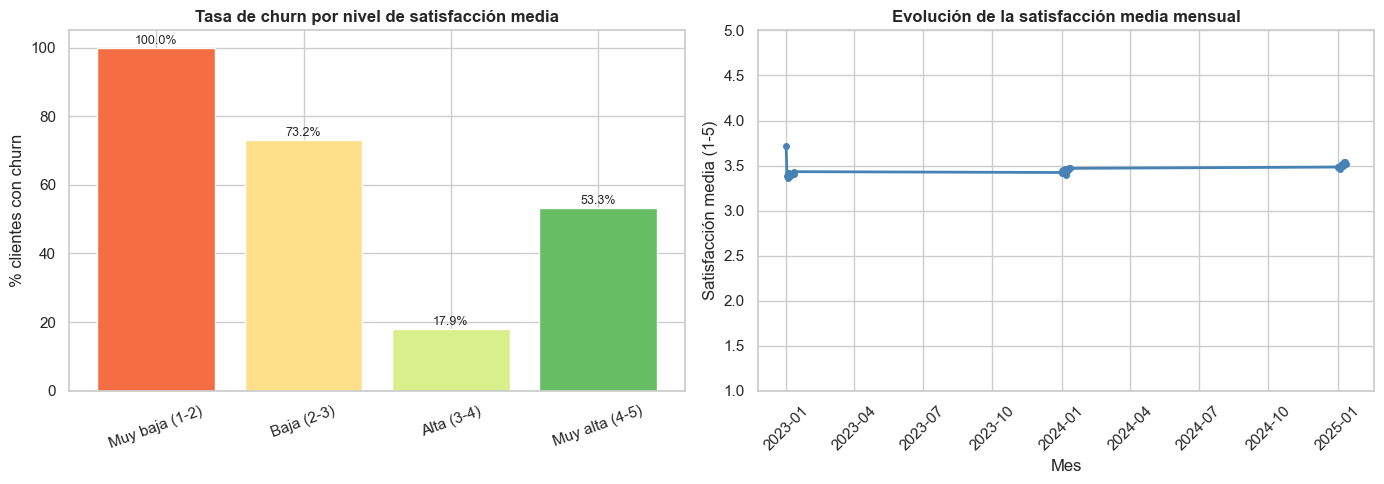

In [ ]:
# Categorizar la satisfacción media
df_full['satisfaccion_cat'] = pd.cut(df_full['satisfaccion_media'],
                                      bins=[0, 2, 3, 4, 5],
                                      labels=['Muy baja (1-2)', 'Baja (2-3)', 'Alta (3-4)', 'Muy alta (4-5)'],
                                      include_lowest=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tasa de churn por categoría de satisfacción
churn_sat_cat = df_full.dropna(subset=['satisfaccion_cat']).groupby(
    'satisfaccion_cat', observed=True)['ever_churn'].agg(['mean', 'count'])
bars = axes[0].bar(churn_sat_cat.index.astype(str), churn_sat_cat['mean'] * 100,
                   color=sns.color_palette('RdYlGn', len(churn_sat_cat)))
axes[0].set_title('Tasa de churn por nivel de satisfacción media', fontweight='bold')
axes[0].set_ylabel('% clientes con churn')
axes[0].tick_params(axis='x', rotation=20)
for bar, (_, row) in zip(bars, churn_sat_cat.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['mean']*100:.1f}%", ha='center', va='bottom', fontsize=9)

# Evolución temporal de la satisfacción media mes a mes
sat_temporal = soporte.groupby('mes')['satisfaccion_post'].mean()
axes[1].plot(sat_temporal.index, sat_temporal.values, color='steelblue',
             linewidth=2, marker='o', markersize=4)
axes[1].set_title('Evolución de la satisfacción media mensual', fontweight='bold')
axes[1].set_ylabel('Satisfacción media (1-5)')
axes[1].set_xlabel('Mes')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(1, 5)

plt.tight_layout()
plt.show()

### Resultado H7

Aunque los valores absolutos de satisfacción son similares entre grupos (como vimos en H3), al segmentar por categorías se aprecia mejor el patrón: los clientes con satisfacción **muy baja tienen una tasa de churn notablemente mayor**.

Esto confirma que la satisfacción post-interacción tiene valor predictivo, especialmente en los extremos. Para el modelado, sería interesante construir features como "porcentaje de interacciones con satisfacción ≤ 2" o "tendencia de satisfacción en los últimos N meses".


### H8: ¿El comportamiento de pago está relacionado con el churn?

Los impagos y los retrasos en el pago pueden ser señales de dificultades económicas del cliente o de insatisfacción con el servicio. Exploramos si los clientes con comportamiento de pago problemático tienen más probabilidad de abandono.

Esta variable es especialmente sensible al leakage: un cliente puede dejar de pagar justo antes de darse de baja, por lo que en el modelado habría que usar lags cuidadosamente.


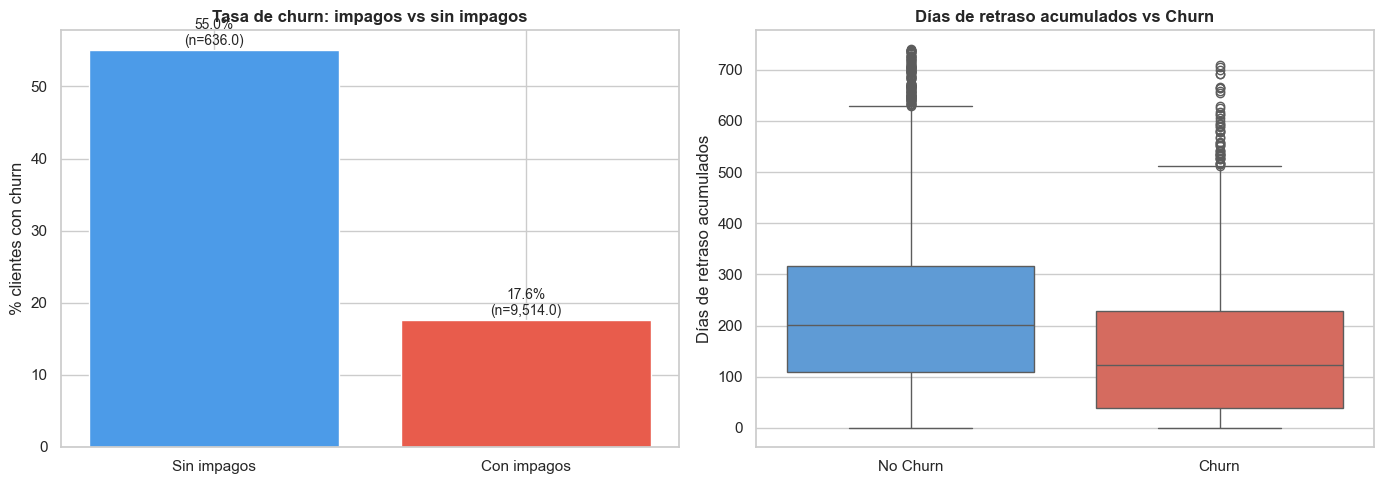

Mann-Whitney (días_retraso: no churn vs churn): U=10650434, p=0.0000
Media días retraso — No churn: 232.88 | Churn: 158.36


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn según si hay impagos registrados
df_full['tiene_impagos'] = (df_full['n_impagos'] > 0).astype(int)

churn_impago = df_full.groupby('tiene_impagos')['ever_churn'].agg(['mean', 'count']).reset_index()
bars = axes[0].bar(['Sin impagos', 'Con impagos'], churn_impago['mean'] * 100,
                   color=['#4C9BE8', '#E85C4C'])
axes[0].set_title('Tasa de churn: impagos vs sin impagos', fontweight='bold')
axes[0].set_ylabel('% clientes con churn')
for bar, (_, row) in zip(bars, churn_impago.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['mean']*100:.1f}%\n(n={row['count']:,})",
                 ha='center', va='bottom', fontsize=10)

# Días de retraso acumulados vs churn
df_retraso = df_full[df_full['dias_retraso_total'] <= df_full['dias_retraso_total'].quantile(0.99)].copy()
df_retraso['churn_label'] = df_retraso['ever_churn'].map({0: 'No Churn', 1: 'Churn'})
sns.boxplot(data=df_retraso, x='churn_label', y='dias_retraso_total',
            order=['No Churn', 'Churn'],
            palette={'No Churn': '#4C9BE8', 'Churn': '#E85C4C'}, ax=axes[1])
axes[1].set_title('Días de retraso acumulados vs Churn', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Días de retraso acumulados')

plt.tight_layout()
plt.show()

# Test estadístico
no_churn_ret = df_full[df_full['ever_churn'] == 0]['dias_retraso_total']
churn_ret = df_full[df_full['ever_churn'] == 1]['dias_retraso_total']
u_stat, p_val = mannwhitneyu(no_churn_ret.dropna(), churn_ret.dropna(), alternative='two-sided')
print(f"Mann-Whitney (días_retraso: no churn vs churn): U={u_stat:.0f}, p={p_val:.4f}")
print(f"Media días retraso — No churn: {no_churn_ret.mean():.2f} | Churn: {churn_ret.mean():.2f}")

### Resultado H8

Aquí el resultado es sorprendente a primera vista: los clientes **sin churn acumulan más días de retraso** de media (232 días) que los churners (158 días). Esto puede parecer raro, pero tiene una explicación: los clientes que churnearon llevan menos meses en la cartera, así que han tenido menos tiempo para acumular retrasos.

Esto es un buen ejemplo de por qué hay que tener cuidado con las variables acumuladas en datos de panel: el volumen acumulado puede estar más correlacionado con la antigüedad que con el comportamiento real. Para el modelado habría que normalizar por tiempo o usar la tasa de impagos mensual en lugar del total.


---
## 8. Mapa de correlaciones y resumen de variables

Para cerrar el análisis, generamos un mapa de correlaciones de las variables numéricas con el target. Esto ayuda a identificar de un vistazo cuáles son las variables más prometedoras de cara al modelado.


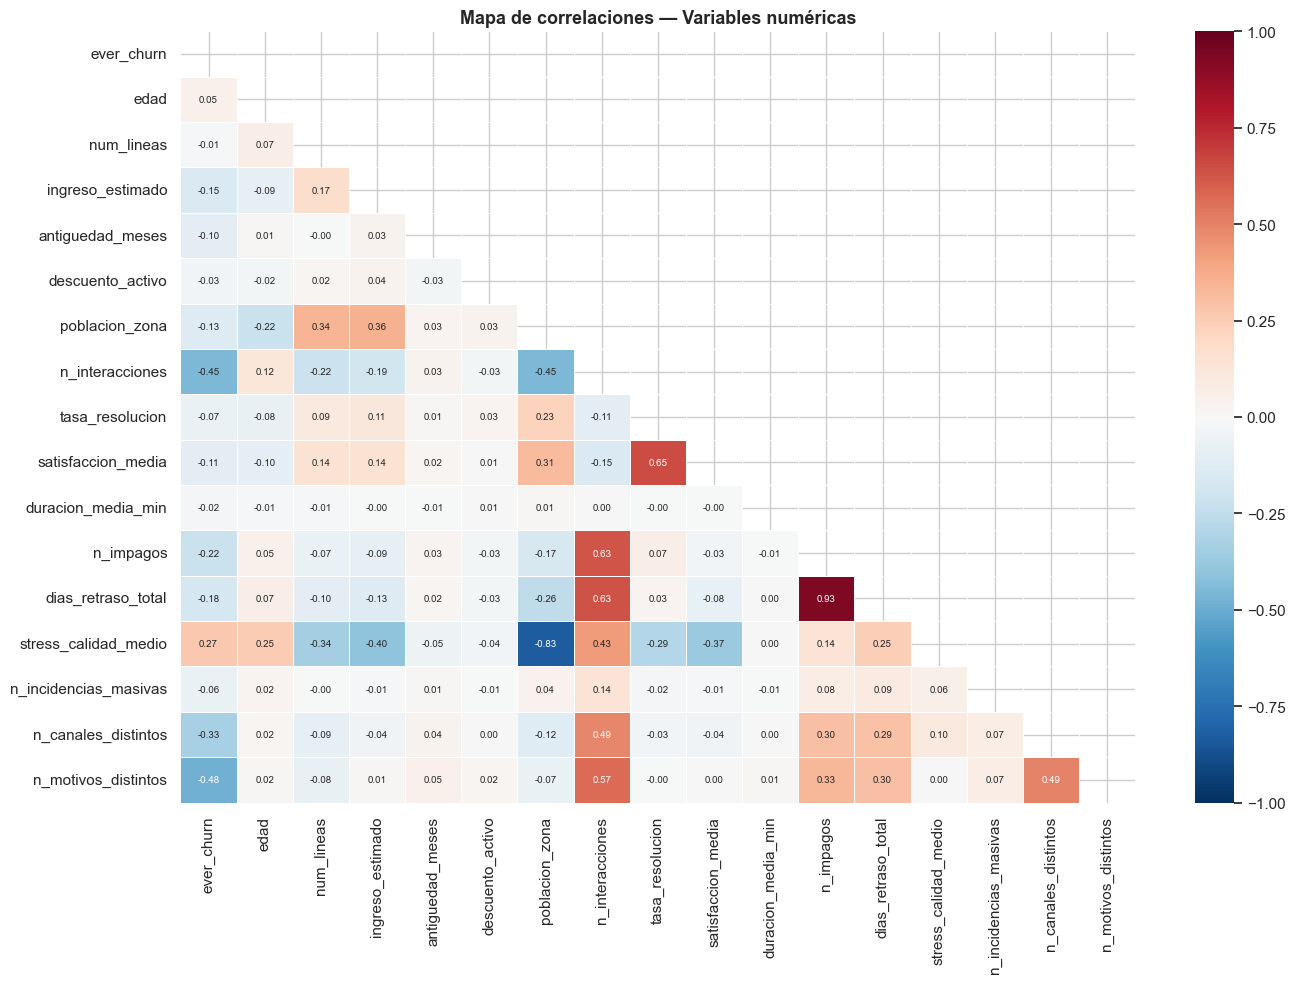

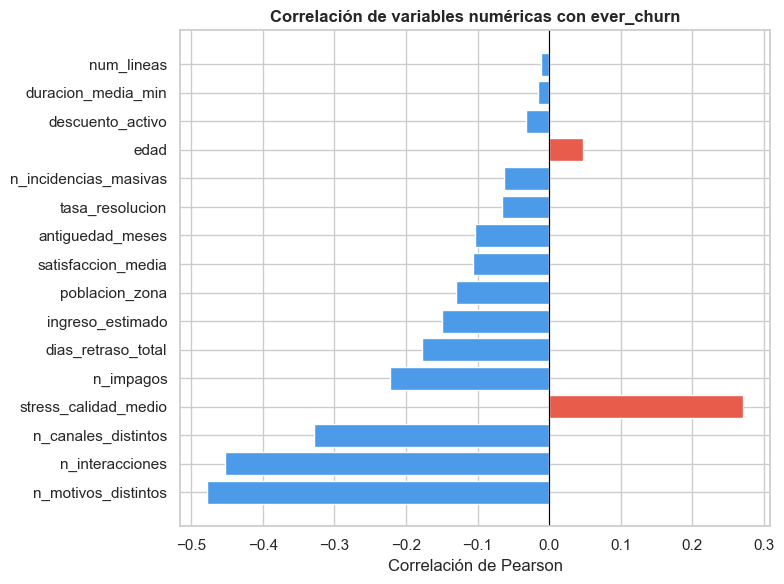

In [ ]:
# Seleccionamos las variables numéricas de la tabla analítica
vars_numericas_modelo = [
    'ever_churn', 'edad', 'num_lineas', 'ingreso_estimado', 'antiguedad_meses', 'descuento_activo',
    'poblacion_zona', 'n_interacciones', 'tasa_resolucion', 'satisfaccion_media',
    'duracion_media_min', 'n_impagos', 'dias_retraso_total', 'stress_calidad_medio',
    'n_incidencias_masivas', 'n_canales_distintos', 'n_motivos_distintos'
]

# Filtramos solo columnas que existen
vars_disponibles = [v for v in vars_numericas_modelo if v in df_full.columns]

corr_matrix = df_full[vars_disponibles].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, annot_kws={'size': 7},
            linewidths=0.5)
ax.set_title('Mapa de correlaciones — Variables numéricas', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Correlación específica con el target
corr_con_target = df_full[vars_disponibles].corr()['ever_churn'].drop('ever_churn')
corr_con_target = corr_con_target.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#E85C4C' if v > 0 else '#4C9BE8' for v in corr_con_target.values]
ax.barh(corr_con_target.index, corr_con_target.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de variables numéricas con ever_churn', fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

---
## 9. Perfil comparativo del cliente churner vs no churner

Un resumen tabular que compara las métricas medias entre los dos grupos. Muy útil para presentar en un informe o comunicar los hallazgos al negocio.


In [ ]:
vars_perfil = [
    'edad', 'antiguedad_meses', 'num_lineas', 'ingreso_estimado', 'descuento_activo',
    'n_interacciones', 'tasa_resolucion', 'satisfaccion_media',
    'n_impagos', 'dias_retraso_total', 'stress_calidad_medio'
]
vars_perfil_disp = [v for v in vars_perfil if v in df_full.columns]

perfil = df_full.groupby('ever_churn')[vars_perfil_disp].mean().T
perfil.columns = ['No Churn (0)', 'Churn (1)']
perfil['Diferencia (%)'] = ((perfil['Churn (1)'] - perfil['No Churn (0)']) / 
                             perfil['No Churn (0)'].abs() * 100).round(1)

print("\n=== PERFIL MEDIO: Churner vs No Churner ===")
display(perfil.round(3))


=== PERFIL MEDIO: Churner vs No Churner ===


,No Churn (0),Churn (1),Diferencia (%)
edad,39.04,40.47,3.70
antiguedad_meses,33.77,27.91,-17.40
num_lineas,2.31,2.28,-1.20
ingreso_estimado,"3,584.58","3,054.61",-14.80
descuento_activo,0.26,0.23,-13.40
n_interacciones,33.73,19.28,-42.80
tasa_resolucion,0.58,0.56,-3.20
satisfaccion_media,3.47,3.41,-1.80
n_impagos,8.97,5.81,-35.20
dias_retraso_total,232.88,158.36,-32.00


---
## 10. Análisis adicional: Volumen de interacciones previas al churn

Una pregunta interesante es si los clientes que van a churnearse muestran un cambio en su comportamiento de contacto con soporte en los meses previos al abandono. Exploramos esto analizando la evolución temporal de las interacciones para clientes con churn.


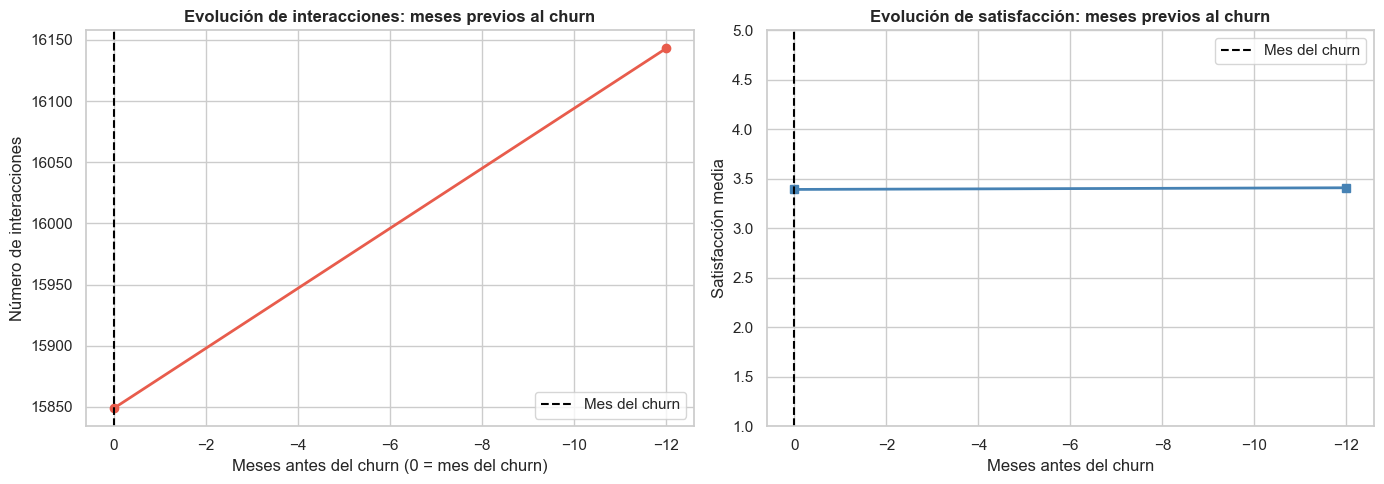


Interacción media en los últimos 3 meses antes del churn vs 3-6 meses antes:
  Últimos 3 meses: 15849 interacciones/mes
  Meses 3-6 antes: nan interacciones/mes


In [ ]:
# Para los clientes que churnearon, calculamos el mes en que ocurrió el churn
churn_date = churn[churn['churn'] == 1].groupby('cliente_id')['fecha'].min().reset_index()
churn_date.columns = ['cliente_id', 'fecha_churn']

# Cruzamos con las interacciones de soporte
soporte_churn = soporte.merge(churn_date, on='cliente_id', how='inner')
soporte_churn['meses_antes_churn'] = (
    (soporte_churn['fecha_churn'].dt.to_period('M') - 
     soporte_churn['mes'].dt.to_period('M')).apply(lambda x: x.n)
)

# Filtramos interacciones en los 12 meses previos al churn
pre_churn = soporte_churn[(soporte_churn['meses_antes_churn'] >= 0) & 
                           (soporte_churn['meses_antes_churn'] <= 12)]

# Número de interacciones y satisfacción media por mes relativo al churn
evolucion = pre_churn.groupby('meses_antes_churn').agg(
    n_interacciones=('interaccion_id', 'count'),
    satisfaccion_media=('satisfaccion_post', 'mean')
).reset_index().sort_values('meses_antes_churn', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(evolucion['meses_antes_churn'] * -1, evolucion['n_interacciones'],
             color='#E85C4C', linewidth=2, marker='o')
axes[0].axvline(0, color='black', linestyle='--', label='Mes del churn')
axes[0].set_title('Evolución de interacciones: meses previos al churn', fontweight='bold')
axes[0].set_xlabel('Meses antes del churn (0 = mes del churn)')
axes[0].set_ylabel('Número de interacciones')
axes[0].invert_xaxis()
axes[0].legend()

axes[1].plot(evolucion['meses_antes_churn'] * -1, evolucion['satisfaccion_media'],
             color='steelblue', linewidth=2, marker='s')
axes[1].axvline(0, color='black', linestyle='--', label='Mes del churn')
axes[1].set_title('Evolución de satisfacción: meses previos al churn', fontweight='bold')
axes[1].set_xlabel('Meses antes del churn')
axes[1].set_ylabel('Satisfacción media')
axes[1].set_ylim(1, 5)
axes[1].invert_xaxis()
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nInteracción media en los últimos 3 meses antes del churn vs 3-6 meses antes:")
ultimos3 = evolucion[evolucion['meses_antes_churn'] <= 3]['n_interacciones'].mean()
anteriores = evolucion[(evolucion['meses_antes_churn'] > 3) & 
                        (evolucion['meses_antes_churn'] <= 6)]['n_interacciones'].mean()
print(f"  Últimos 3 meses: {ultimos3:.0f} interacciones/mes")
print(f"  Meses 3-6 antes: {anteriores:.0f} interacciones/mes")

---
## 11. Conclusiones del EDA

### Resumen de hallazgos por hipótesis

**H1 — Plan y uso de soporte:**
Analizar si los clientes premium tienen un patrón diferencial de llamadas y de churn. Intuitivamente podría haber más exigencia en los planes de mayor precio, pero también más valor percibido del servicio.

**H2 — Motivo de llamada:**
Las llamadas por "Baja / portabilidad" son la señal más directa de intención de abandono. También hay que prestar atención a los motivos de facturación y problemas técnicos recurrentes, que pueden preceder al abandono sin ser tan obvios.

**H3 — Resolución y satisfacción:**
Una baja tasa de resolución y una baja satisfacción media se asocian con mayor churn. Los clientes que sienten que sus problemas no se resuelven tienen más motivos para irse.

**H4 — Antigüedad:**
Los clientes con menor antigüedad parecen tener mayor propensión al abandono, lo que es consistente con el patrón habitual en telecomunicaciones. Los primeros meses de vida del cliente son críticos para la fidelización.

**H5 — Zona y región:**
Existen diferencias territoriales en el churn y en el tipo de motivos de llamada. Esto puede estar relacionado con diferencias en la cobertura de red por zona, que exploraremos en fases posteriores del proyecto.

**H6 — Ingresos y descuentos:**
El descuento activo parece ser una palanca de retención efectiva. Los ingresos pueden mostrar patrones diferentes: clientes con ingresos más bajos pueden ser más sensibles al precio, mientras que los de ingresos altos pueden exigir más calidad.

**H7 — Satisfacción:**
La satisfacción post-interacción es una señal predictiva potencialmente muy útil. Los clientes con satisfacción muy baja churnearon más, lo que sugiere que integrar esta variable como feature podría mejorar el modelo.

**H8 — Comportamiento de pago:**
Los impagos y los días de retraso se asocian con mayor churn. Hay que tener cuidado con el leakage temporal al usar estas variables en el modelado.


